# Robustness metrics on Generative Forests
Requires Python 3.7

This code reproduces the experiment conducted in section 3.1.1

In [1]:
# Loading all libraries
import pickle
import numpy as np
import pandas as pd
from os import getcwd
from gefs import compute_rob_class
from gefs.sklearn_utils import rf2pc
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from gefrob import *
from plotting import combine_plots_acc_rej

In [2]:
path="./datasets/"

In [3]:
datasets=['waveform_21','students']

In [4]:
B = 1 # Number of samples used for obtaining mean of accuracies
p = 0.3 # Proportion of the data used as the test set
k_cv = 5
fs = (10, 5)

## Obtaining our robustness metric and the GeF local metric for each of the listed datasets

In [6]:
gef_robust={}
for ds in datasets:
    print("Obtaining the robustness metrics for the "+ds+" dataset.")
    df = pd.read_csv(path+ds+".csv")
    y=df.loc[:,df.columns[-1]]
    if y.dtype == 'object':
        y = pd.Categorical(y).codes
    elif y.dtype=='int':
        y = y-y.min()
    cats=np.sort(np.unique(y))
    X=df.loc[:,df.columns[:-1]]
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = pd.Categorical(X[col]).codes
    # Defining model
    rf = RandomForestClassifier(random_state = 7)
    param_grid = {
        'n_estimators': [100, 200],
        'max_features': ['sqrt', 'log2'],
        'max_depth': [5, None],
        'min_samples_split': [2, 5]
    }
    rf_grid = GridSearchCV(rf, param_grid, cv=k_cv, scoring='neg_log_loss', n_jobs = -1)
    
    gef_robust[ds] = gef_rob(X, y, cats, model = rf_grid, B=B, test_size=p)

Obtaining the robustness metrics for the waveform_21 dataset.
Obtaining the robustness metrics for the students dataset.


In [7]:
# Saving the essential information of the analysis
with open('gef_rob.pickle', 'wb') as handle:
    pickle.dump(gef_robust, handle, protocol=pickle.HIGHEST_PROTOCOL)

## Mean of the ARC for the GeF model for each robustness metric and dataset

In [8]:
with open('gef_rob.pickle', 'rb') as handle:
    gef_robust = pickle.load(handle)

In [9]:
dict_wav = {
            r"$r_{GeF}$": gef_robust["waveform_21"]['local_rob'],
            r"$r_{d_{COR}}$": gef_robust["waveform_21"]['ratio_rob']
           }
class_wav = gef_robust["waveform_21"]['class_resul']


AUC:  0.957027581657219

AUC:  0.9639788149486849


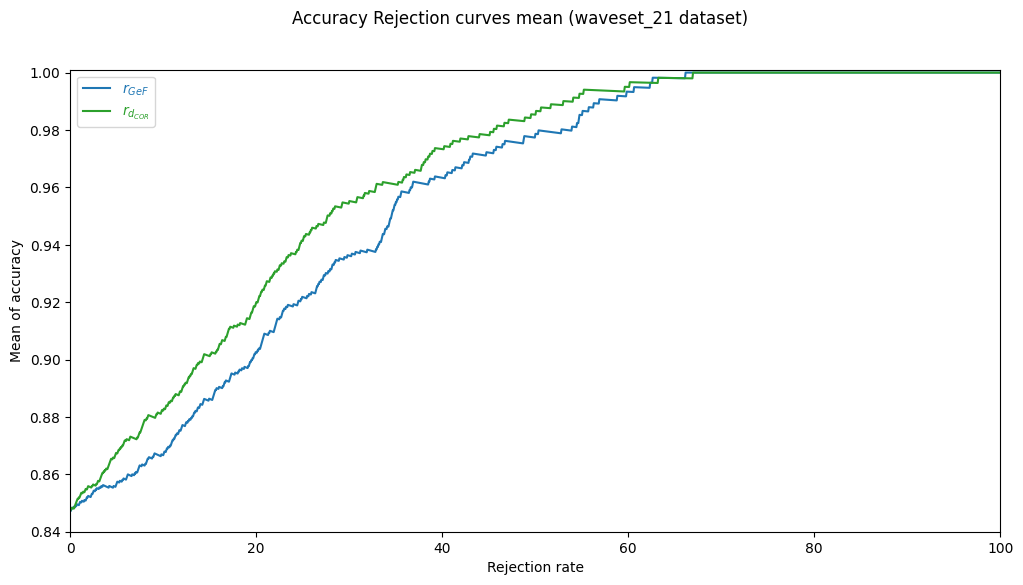

In [10]:
combine_plots_acc_rej(rob_measures = dict_wav,
                      classification_results = class_wav, fig_size=(12,6), mean=True,
                      show=True, title_extra="(waveset_21 dataset)", y_min=0.84, legend_loc='upper left', AUC=True)

In [11]:
dict_stu = {
            r"$r_{GeF}$": gef_robust["students"]['local_rob'],
            r"$r_{d_{COR}}$": gef_robust["students"]['ratio_rob']
           }
class_stu = gef_robust["students"]['class_resul']


AUC:  0.7535127557193813

AUC:  0.8388047685695302


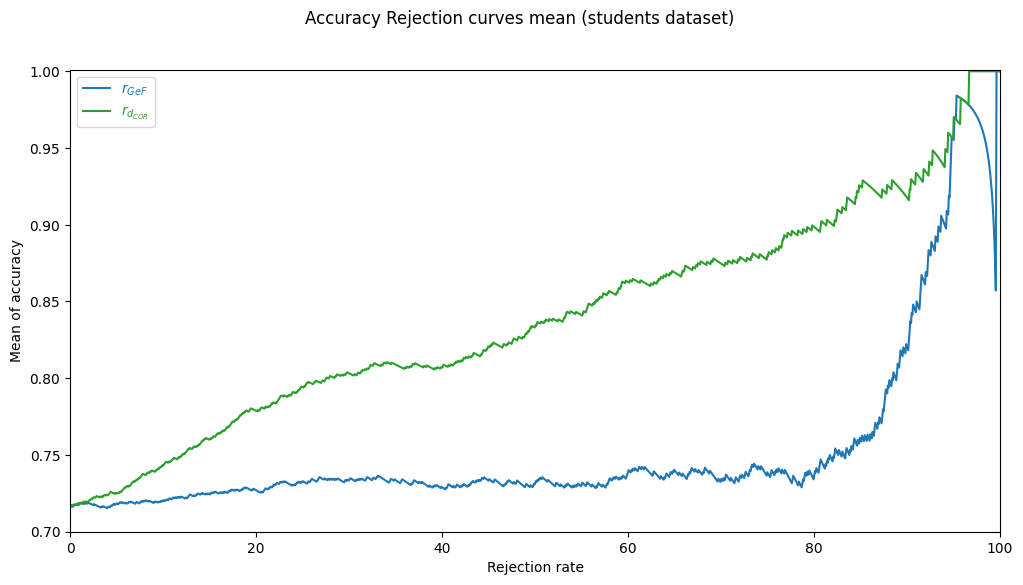

In [12]:
combine_plots_acc_rej(rob_measures = dict_stu,
                      classification_results = class_stu, fig_size=(12,6), mean=True,
                      show=True, title_extra="(students dataset)", y_min=0.7, legend_loc='upper left', AUC=True)